# Preprocessing & EDA
## Healthcare Sector Focus

**Goal**: Analyse the UK ICO data security incident trends with a focus on the healthcare sector to prepare for building ML models and a dashboard.


In [67]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from kmodes.kmodes import KModes

In [68]:
# load the dataset
df_ico_original = pd.read_csv("data-security-incidents-trends-q1-2019-to-q4-2025.csv", delimiter = ",")

# initial look at data
df_ico_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206140 entries, 0 to 206139
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   BI Reference                206140 non-null  object
 1   Year                        206140 non-null  int64 
 2   Quarter                     206140 non-null  object
 3   Data Subject Type           206140 non-null  object
 4   Data Type                   206140 non-null  object
 5   Decision Taken              206140 non-null  object
 6   Incident Category           206140 non-null  object
 7   Incident Type               206140 non-null  object
 8   No. Data Subjects Affected  206140 non-null  object
 9   Sector                      206140 non-null  object
 10  Time Taken to Report        206140 non-null  object
dtypes: int64(1), object(10)
memory usage: 17.3+ MB



Total sectors: 23


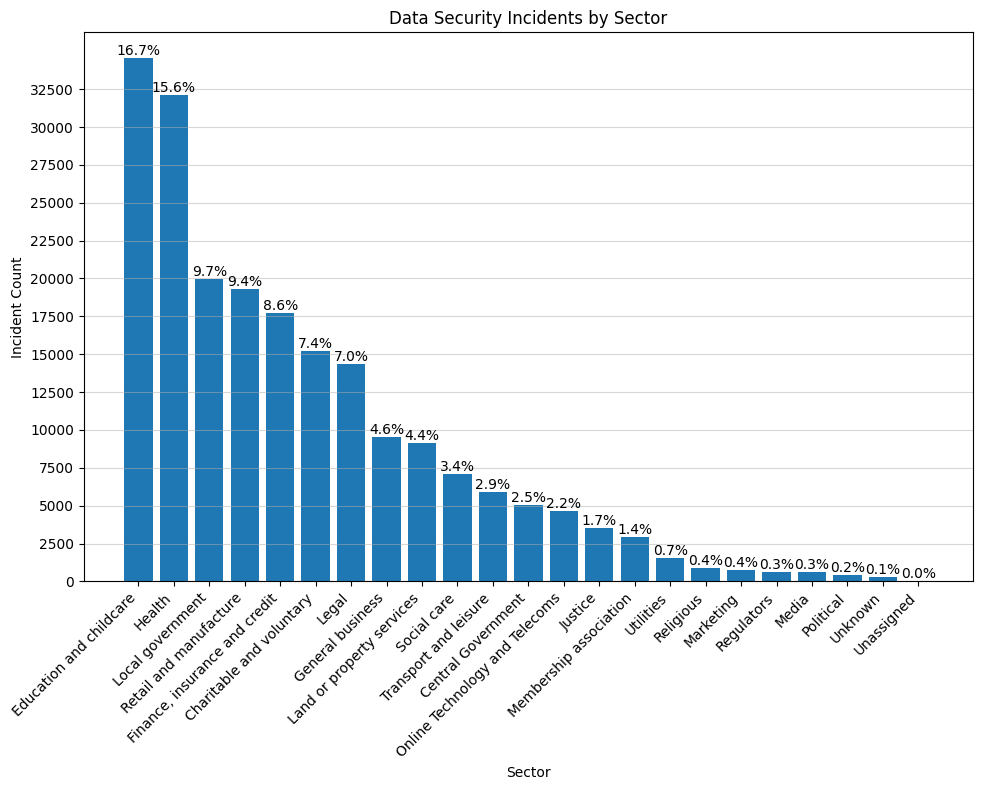

In [69]:
# count all sectors
sector_counts = df_ico_original['Sector'].value_counts()
sector_percents = sector_counts / len(df_ico_original) * 100

plt.figure(figsize=(10, 8))
bars = plt.bar(sector_counts.index, sector_counts.values)

plt.title("Data Security Incidents by Sector")
plt.xlabel("Sector")
plt.ylabel("Incident Count")
plt.xticks(rotation=45, ha='right')
plt.yticks(np.arange(0, max(sector_counts.values) + 1, 2500))

# add percentage labels on top of each bar
for bar, percent in zip(bars, sector_percents):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, # put percentage in the middle
        height, f"{percent:.1f}%",
        ha='center', va='bottom'
    )

print(f"\nTotal sectors: {df_ico_original['Sector'].nunique()}")
plt.grid(True, axis='y', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

In [70]:
# Sector table with counts and percentages
sector_table = pd.DataFrame({
    'Incident Count': sector_counts,
    'Percentage': sector_percents.round(3)
})
sector_table


,Incident Count,Percentage
Sector,,
Education and childcare,34525,16.748
Health,32127,15.585
Local government,19991,9.698
Retail and manufacture,19308,9.366
"Finance, insurance and credit",17744,8.608
Charitable and voluntary,15229,7.388
Legal,14329,6.951
General business,9520,4.618
Land or property services,9148,4.438


In [71]:
# filtering the database to focus of the health sector
df_health_original = df_ico_original[df_ico_original["Sector"] == "Health"].copy(deep=True)

# drop the sector column as it's redundant now
df_health_original = df_health_original.drop(columns=["Sector"])

# standardising the column names
df_health_original.columns = df_health_original.columns.str.strip().str.lower().str.replace(" ", "_").str.replace(".", "")

# look at new healthcare sector focused df
df_health_original.info()
#df_health_original.to_csv("data-security-incident-trends-health-sector.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 32127 entries, 12 to 206136
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   bi_reference               32127 non-null  object
 1   year                       32127 non-null  int64 
 2   quarter                    32127 non-null  object
 3   data_subject_type          32127 non-null  object
 4   data_type                  32127 non-null  object
 5   decision_taken             32127 non-null  object
 6   incident_category          32127 non-null  object
 7   incident_type              32127 non-null  object
 8   no_data_subjects_affected  32127 non-null  object
 9   time_taken_to_report       32127 non-null  object
dtypes: int64(1), object(9)
memory usage: 2.7+ MB


In [72]:
# filtering timeframe to Q2 2021 to Q2 2025

# Get quarters as int for filtering
df_health_original["quarter_num"] = df_health_original["quarter"].str.extract(r"(\d)").astype(int) # temp, helper column 

df_health_original = df_health_original[
    ((df_health_original["year"] > 2021) | ((df_health_original["year"] == 2021) & (df_health_original["quarter_num"] >= 2))) &
    ((df_health_original["year"] < 2025) | ((df_health_original["year"] == 2025) & (df_health_original["quarter_num"] <= 4)))
]

df_health_original = df_health_original.drop(columns="quarter_num") # drop 

# Test to see full timeframe
print(df_health_original[["year", "quarter"]].drop_duplicates().sort_values(["year", "quarter"]).to_string(index=False))

# New CSV of all processed data
#df_health_original.to_csv("data-security-incident-trends-health-sector.csv", index=False)

 year quarter
 2021   Qtr 2
 2021   Qtr 3
 2021   Qtr 4
 2022   Qtr 1
 2022   Qtr 2
 2022   Qtr 3
 2022   Qtr 4
 2023   Qtr 1
 2023   Qtr 2
 2023   Qtr 3
 2023   Qtr 4
 2024   Qtr 1
 2024   Qtr 2
 2024   Qtr 3
 2024   Qtr 4
 2025   Qtr 1
 2025   Qtr 2
 2025   Qtr 3
 2025   Qtr 4


In [73]:
# change data type of features into categorical instead of object/ int as characteristics are fixed
categorical_cols = [
    "bi_reference",
    "year",
    "quarter",
    "data_subject_type",
    "data_type",
    "decision_taken",
    "incident_category",
    "incident_type",
    "no_data_subjects_affected",
    "time_taken_to_report"
]


for col in categorical_cols:
    df_health_original[col] = df_health_original[col].astype("category")

# verify new data types
df_health_original.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22879 entries, 65264 to 206136
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   bi_reference               22879 non-null  category
 1   year                       22879 non-null  category
 2   quarter                    22879 non-null  category
 3   data_subject_type          22879 non-null  category
 4   data_type                  22879 non-null  category
 5   decision_taken             22879 non-null  category
 6   incident_category          22879 non-null  category
 7   incident_type              22879 non-null  category
 8   no_data_subjects_affected  22879 non-null  category
 9   time_taken_to_report       22879 non-null  category
dtypes: category(10)
memory usage: 764.5 KB


In [74]:
# Order the data subjects affected category
df_health_original["no_data_subjects_affected"] = pd.Categorical(
    df_health_original["no_data_subjects_affected"],
    categories=[
        "1 to 9",
        "10 to 99",
        "100 to 1k",
        "1k to 10k",
        "10k to 100k",
        "100k and above",
        "Unknown"
    ],
    ordered=True
)

# verify ordering
df_health_original["no_data_subjects_affected"].cat.categories

Index(['1 to 9', '10 to 99', '100 to 1k', '1k to 10k', '10k to 100k',
       '100k and above', 'Unknown'],
      dtype='object')

In [75]:
# finding the unique vs total BI references 
total_rows = len(df_health_original)
unique_bi_refs = df_health_original['bi_reference'].nunique()
duplicate_ratio = (total_rows - unique_bi_refs) / total_rows * 100

print(f"\nTotal rows in the dataset: {total_rows:,}")
print(f"Unique BI References: {unique_bi_refs:,}")
print(f"Rows representing duplicate characteristics: {total_rows - unique_bi_refs:,}")
print(f"Duplication rate: {duplicate_ratio:.2f}%")


Total rows in the dataset: 22,879
Unique BI References: 10,098
Rows representing duplicate characteristics: 12,781
Duplication rate: 55.86%


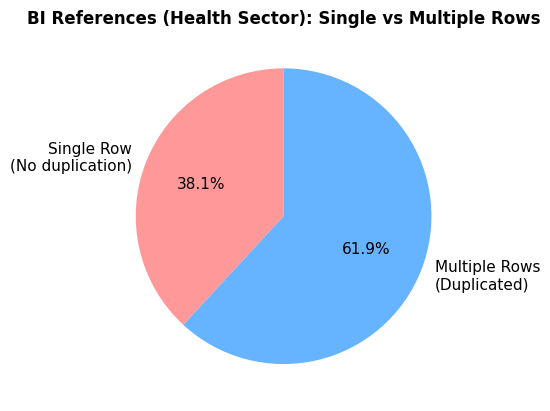

In [76]:
# plot: pie chart of unique vs duplicate references
bi_ref_counts = df_health_original['bi_reference'].value_counts()
single_row = (bi_ref_counts == 1).sum()
multiple_rows = (bi_ref_counts > 1).sum()

plt.pie([single_row, multiple_rows], 
            labels=['Single Row\n(No duplication)', 'Multiple Rows\n(Duplicated)'], 
            autopct='%1.1f%%',
            colors=['#ff9999', '#66b3ff'],
            startangle=90,
            textprops={'fontsize': 11})

plt.title('BI References (Health Sector): Single vs Multiple Rows', fontsize=12, fontdict={'weight': 'bold'})
plt.show()

In [77]:
# analyse which columns typically vary across duplicates
duplicated_bi_refs = df_health_original[df_health_original['bi_reference'].duplicated(keep=False)]
total_groups = duplicated_bi_refs['bi_reference'].nunique()

# nunique per group per column
varying_columns = duplicated_bi_refs.groupby("bi_reference", observed=False).nunique()

# a column varies in a group if nunique > 1
varying_counts = (varying_columns > 1).sum()

varying_counts = (varying_counts
    .sort_values(ascending=False)
    .rename("count")
    .to_frame()
)

varying_counts["percentage"] = (varying_counts["count"] / total_groups * 100)

print(f"Columns that vary across duplicate rows:\n {varying_counts}")

# summarise how many characteristics each breach has
print("\nBreach characteristics per incident:")
df_health_original.groupby("bi_reference", observed=False).size().describe()

Columns that vary across duplicate rows:
                            count  percentage
data_type                   5675   90.843605
data_subject_type           1689   27.036978
year                           0    0.000000
quarter                        0    0.000000
decision_taken                 0    0.000000
incident_category              0    0.000000
incident_type                  0    0.000000
no_data_subjects_affected      0    0.000000
time_taken_to_report           0    0.000000

Breach characteristics per incident:


count    10098.000000
mean         2.265696
std          2.808294
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         66.000000
dtype: float64

Missing values in the healthcare dataset:
bi_reference                 0
year                         0
quarter                      0
data_subject_type            0
data_type                    0
decision_taken               0
incident_category            0
incident_type                0
no_data_subjects_affected    0
time_taken_to_report         0
dtype: int64


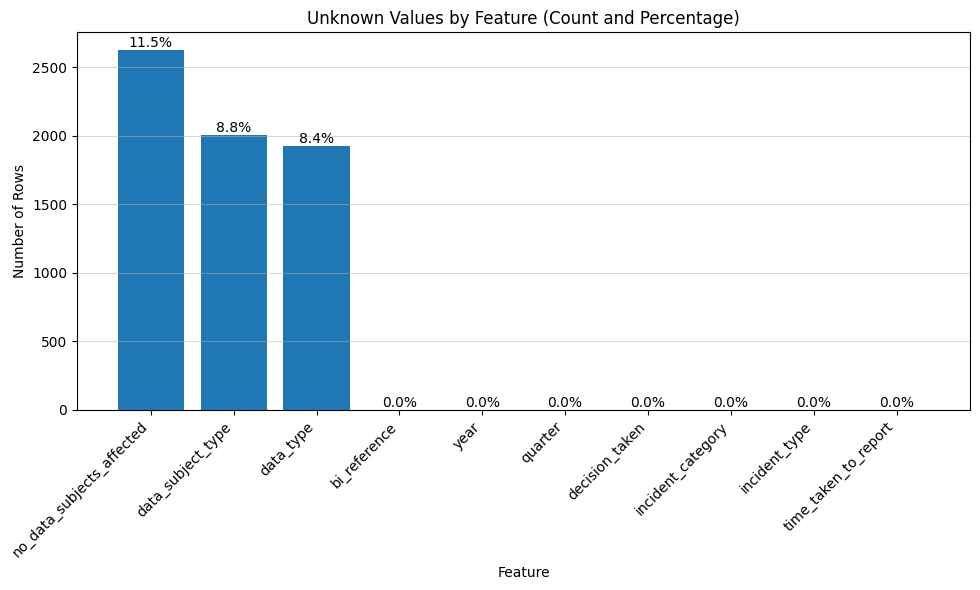

Unknown characteristic counts in each feature:
no_data_subjects_affected    2625
data_subject_type            2009
data_type                    1929
bi_reference                    0
year                            0
quarter                         0
decision_taken                  0
incident_category               0
incident_type                   0
time_taken_to_report            0
dtype: int64


In [78]:
# checking how many missing/ unknown values are in the healthcare df
print(f"Missing values in the healthcare dataset:\n{df_health_original.isnull().sum()}")

unknown_counts = df_health_original[categorical_cols].isin(["Unknown"]).sum().sort_values(ascending=False)

# calculate percentages
unknown_percents = (unknown_counts / len(df_health_original)) * 100

# visualise per feature
plt.figure(figsize=(10, 6))
bars = plt.bar(unknown_counts.index, unknown_counts.values)

plt.title("Unknown Values by Feature (Count and Percentage)")
plt.xlabel("Feature")
plt.ylabel("Number of Rows")
plt.xticks(rotation=45, ha="right")

# add percentage labels
for bar, percent in zip(bars, unknown_percents):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height, f"{percent:.1f}%",
        ha="center", va="bottom"
    )

plt.grid(True, axis='y', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()
print(f"Unknown characteristic counts in each feature:\n{unknown_counts}")

In [79]:
# Create a new df that only contains unique BI references (deduplicated)
df_health_unique = df_health_original.drop_duplicates(subset=["bi_reference"], keep="first").reset_index(drop=True)
print("Unique Rows in Health Sector df:",unique_bi_refs)

Unique Rows in Health Sector df: 10098


In [80]:
# aggregate total rows per year-quarter (duplicated BI references)
total_incidents = (
    df_health_original
    .groupby(["year", "quarter"], observed=True) 
    .size()
    .reset_index(name="total_incidents")
)

# aggregate unique incidents per year-quarter (non-duplicated BI references)
unique_incidents = (
    df_health_unique
    .groupby(["year", "quarter"], observed=True)  
    .size()
    .reset_index(name="unique_incidents")
)

quarters = {"Qtr 1": 1, "Qtr 2": 2, "Qtr 3": 3, "Qtr 4": 4}

# merge the two summaries
incidents_over_time = total_incidents.merge(unique_incidents, on=["year", "quarter"])

# make the chronological order
incidents_over_time["quarter_num"] = incidents_over_time["quarter"].astype(str).map(quarters)

# convert year to int for sorting
incidents_over_time["year_num"] = incidents_over_time["year"].astype(str).astype(int)
incidents_over_time = incidents_over_time.sort_values(by=["year_num", "quarter_num"]).reset_index(drop=True)

# x-axis label
incidents_over_time["period"] = (incidents_over_time["year"].astype(str) + " " + incidents_over_time["quarter"].astype(str))

# copy for display purposes
display_df = incidents_over_time[["year", "quarter", "total_incidents", "unique_incidents"]].copy()
# calculate the difference (duplicate count) & percentage of duplicates
display_df["duplicates"] = display_df["total_incidents"] - display_df["unique_incidents"]
# display columns
display_df.columns = ["Year", "Quarter", "Total Rows", "Unique Incidents", "Duplicates"]

# tabular form
print("Healthcare data security incidents over time:")
print(display_df.to_string(index=False))

# summary statistics
print(f"\nOverall Summary:")
print(f"\tTotal rows across all periods: {display_df['Total Rows'].sum():,}")
print(f"\tTotal unique incidents: {display_df['Unique Incidents'].sum():,}")
print(f"\tTotal duplicate incidents: {display_df['Duplicates'].sum():,}")

# mean and standard deviations of unique incidents over time 
print(f"\tMean incidents per quarter: {display_df['Unique Incidents'].mean():.1f}")
print(f"\tStandard deviation of incidents: {display_df['Unique Incidents'].std():.1f}")
print(f"\tMaximum incidents in a quarter: {display_df['Unique Incidents'].max():,}")
print(f"\tMinimum incidents in a quarter: {display_df['Unique Incidents'].min():,}")

Healthcare data security incidents over time:
Year Quarter  Total Rows  Unique Incidents  Duplicates
2021   Qtr 2        1286               603         683
2021   Qtr 3         915               432         483
2021   Qtr 4         991               461         530
2022   Qtr 1         913               421         492
2022   Qtr 2         937               431         506
2022   Qtr 3        1548               481        1067
2022   Qtr 4         938               440         498
2023   Qtr 1        1077               454         623
2023   Qtr 2        1019               458         561
2023   Qtr 3        1038               501         537
2023   Qtr 4        1191               503         688
2024   Qtr 1        1245               572         673
2024   Qtr 2        1497               616         881
2024   Qtr 3        1620               677         943
2024   Qtr 4        1154               577         577
2025   Qtr 1        1231               582         649
2025   Qtr 2       

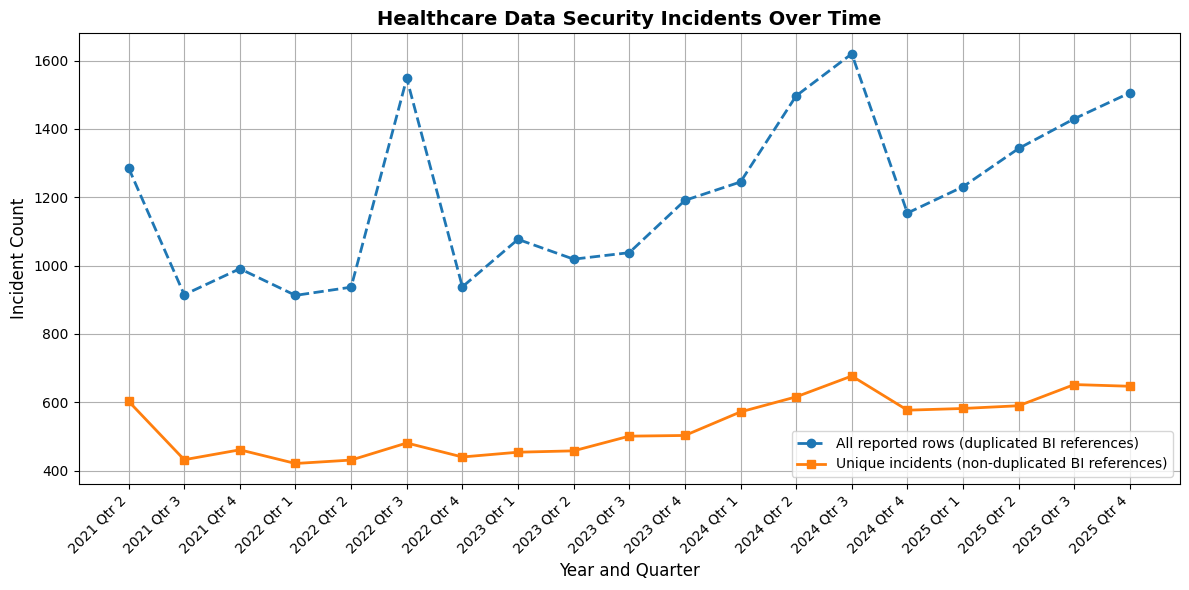

In [81]:
# graph visualisation of incidents 
plt.figure(figsize=(12, 6))

plt.plot(
    incidents_over_time.index,
    incidents_over_time["total_incidents"],
    marker='o',
    label="All reported rows (duplicated BI references)",
    linestyle="--",
    linewidth=2,
    markersize=6
)

plt.plot(
    incidents_over_time.index,
    incidents_over_time["unique_incidents"],
    marker='s',
    label="Unique incidents (non-duplicated BI references)",
    linewidth=2,
    markersize=6
)

plt.xticks(
    ticks=incidents_over_time.index,
    labels=incidents_over_time["period"],
    rotation=45, ha='right'
)

plt.title("Healthcare Data Security Incidents Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Year and Quarter", fontsize=12)
plt.ylabel("Incident Count", fontsize=12)
plt.legend(loc='best', frameon=True)
plt.grid(True, linestyle='-')
plt.tight_layout()
plt.show()

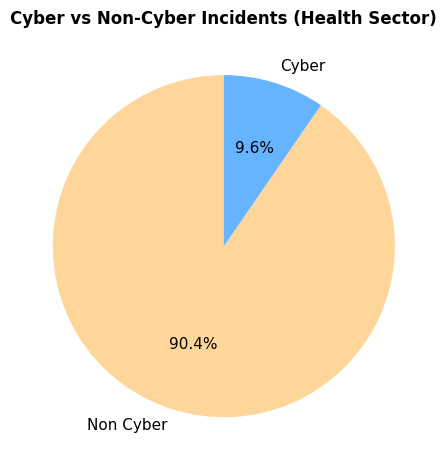

Incident category counts (Cyber vs Non-cyber):
Cyber: 969 
Non-Cyber: 9,129


In [82]:
# cyber vs non-cyber incidents
incident_category_counts = df_health_unique['incident_category'].value_counts()
incident_category_percents = (incident_category_counts / len(df_health_original)) * 100

plt.title("Cyber vs Non-Cyber Incidents (Health Sector)", fontsize=12, fontweight='bold')
plt.pie(incident_category_counts.values,
        labels=incident_category_counts.index,
        autopct='%1.1f%%',
        colors=["#ffd699", "#66b3ff"],
        startangle=90,
        textprops={'fontsize': 11})

plt.tight_layout()
plt.show()
print(f"Incident category counts (Cyber vs Non-cyber):\nCyber: {incident_category_counts['Cyber']:,} \nNon-Cyber: {incident_category_counts['Non Cyber']:,}")

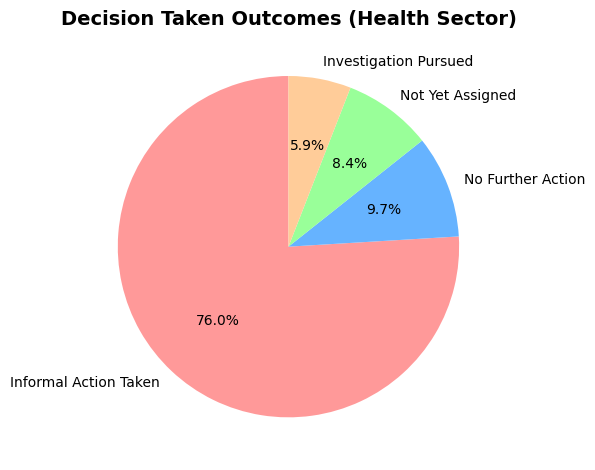

Decision taken counts:
Informal Action Taken:	7,670 
No Further Action:	982 
Investigation Pursued:	598 
Not Yet Assigned:	848


In [83]:
# decision taken outcomes
decision_counts = df_health_unique['decision_taken'].value_counts()
decision_percents = (decision_counts / len(df_health_original)) * 100

# pie chart
plt.title("Decision Taken Outcomes (Health Sector)", fontsize=14, fontweight='bold')
plt.pie(decision_counts.values,
        labels=decision_counts.index,
        autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'],
        startangle=90,
        textprops={'fontsize': 10})

plt.tight_layout()
plt.show()

print(f"Decision taken counts:\nInformal Action Taken:\t{decision_counts['Informal Action Taken']:,} \nNo Further Action:\t{decision_counts['No Further Action']:,} \nInvestigation Pursued:\t{decision_counts['Investigation Pursued']:,} \nNot Yet Assigned:\t{decision_counts['Not Yet Assigned']:,}")


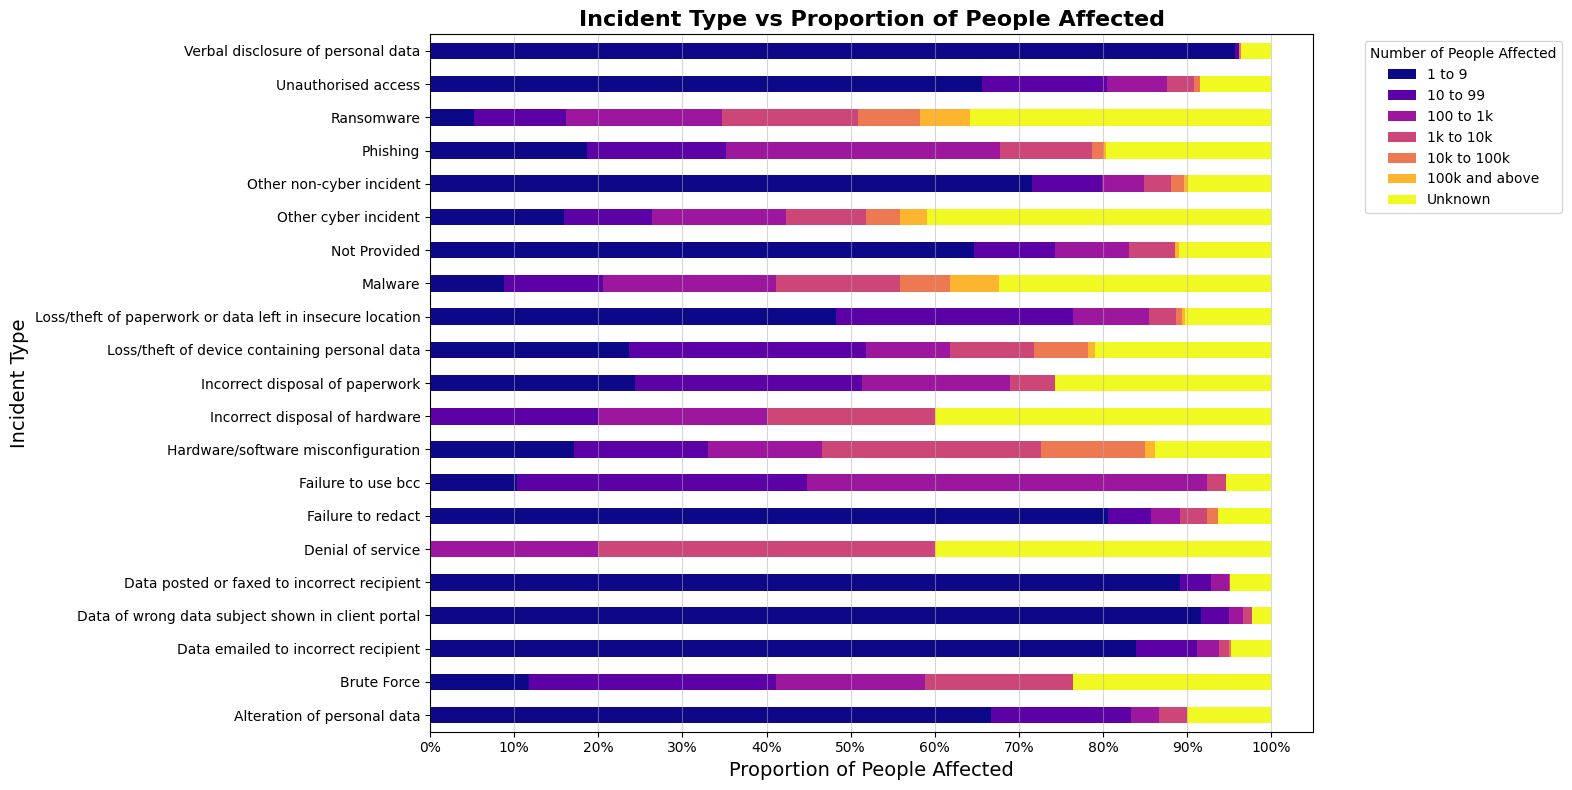

no_data_subjects_affected,1 to 9,10 to 99,100 to 1k,1k to 10k,10k to 100k,100k and above,Unknown
incident_type,,,,,,,
Alteration of personal data,0.667,0.167,0.033,0.033,0.000,0.000,0.100
Brute Force,0.118,0.294,0.176,0.176,0.000,0.000,0.235
Data emailed to incorrect recipient,0.840,0.072,0.027,0.011,0.002,0.000,0.048
Data of wrong data subject shown in client portal,0.916,0.034,0.017,0.010,0.000,0.000,0.024
Data posted or faxed to incorrect recipient,0.892,0.037,0.021,0.001,0.000,0.001,0.049
Denial of service,0.000,0.000,0.200,0.400,0.000,0.000,0.400
Failure to redact,0.806,0.052,0.034,0.032,0.012,0.000,0.064
Failure to use bcc,0.103,0.345,0.475,0.022,0.000,0.000,0.054
Hardware/software misconfiguration,0.171,0.159,0.136,0.260,0.124,0.012,0.139


In [84]:
# incident type vs data subjects affected

# proportions
incident_severity_proportions = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['no_data_subjects_affected'],
    normalize='index'
)
# counts
incident_severity_counts = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['no_data_subjects_affected']
)
# horizontal bar chart
incident_severity_proportions.plot(
    kind='barh',
    stacked=True,
    figsize=(16, 8),
    colormap='plasma'
)

plt.title('Incident Type vs Proportion of People Affected', fontsize=16, fontweight='bold')
plt.ylabel('Incident Type', fontsize=14)
plt.xlabel('Proportion of People Affected', fontsize=14)
plt.xticks(np.arange(0, 1.1, 0.1), [f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)])
plt.legend(title='Number of People Affected', bbox_to_anchor=(1.05, 1), loc='best')
plt.grid(True, axis='x', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

# display the incident type vs data subjects affected proportions
incident_severity_proportions.round(3)

In [85]:
# display the incident type vs data subjects affected counts
incident_severity_counts

no_data_subjects_affected,1 to 9,10 to 99,100 to 1k,1k to 10k,10k to 100k,100k and above,Unknown
incident_type,,,,,,,
Alteration of personal data,20,5,1,1,0,0,3
Brute Force,2,5,3,3,0,0,4
Data emailed to incorrect recipient,1319,113,42,18,3,0,76
Data of wrong data subject shown in client portal,272,10,5,3,0,0,7
Data posted or faxed to incorrect recipient,898,37,21,1,0,1,49
Denial of service,0,0,1,2,0,0,2
Failure to redact,328,21,14,13,5,0,26
Failure to use bcc,23,77,106,5,0,0,12
Hardware/software misconfiguration,58,54,46,88,42,4,47


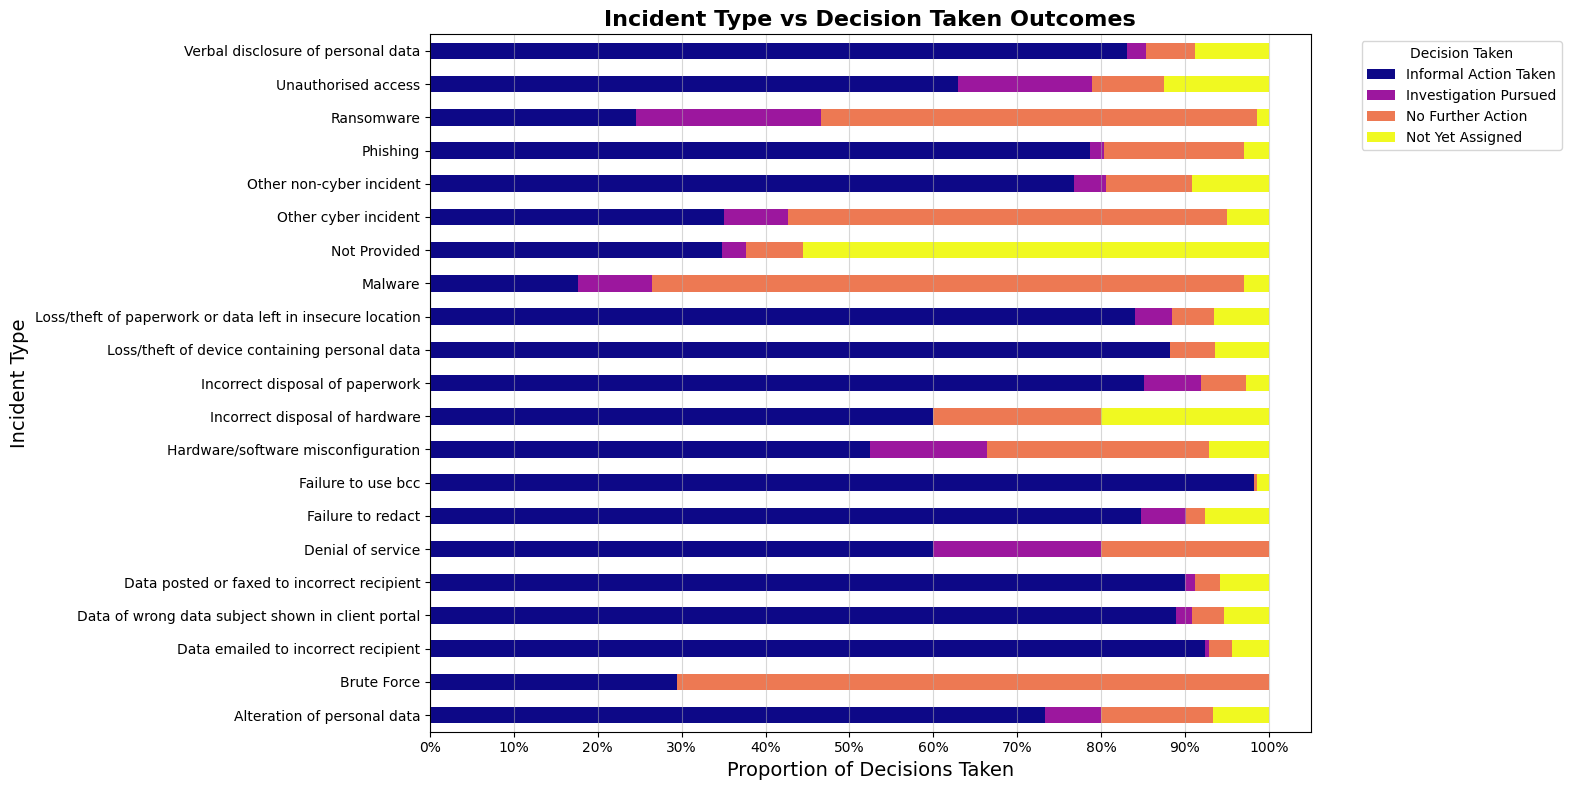

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action,Not Yet Assigned
incident_type,,,,
Alteration of personal data,0.733,0.067,0.133,0.067
Brute Force,0.294,0.000,0.706,0.000
Data emailed to incorrect recipient,0.924,0.005,0.028,0.043
Data of wrong data subject shown in client portal,0.889,0.020,0.037,0.054
Data posted or faxed to incorrect recipient,0.901,0.011,0.031,0.058
Denial of service,0.600,0.200,0.200,0.000
Failure to redact,0.848,0.054,0.022,0.076
Failure to use bcc,0.982,0.000,0.004,0.013
Hardware/software misconfiguration,0.525,0.139,0.265,0.071


In [86]:
# decision taken vs incident Type

# proportions
incident_type_decision_proportions = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['decision_taken'],
    normalize='index'
)
# counts
incident_type_decision_counts = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['decision_taken']
)
# horizontal bar chart
incident_type_decision_proportions.plot(
    kind='barh',
    stacked=True,
    figsize=(16, 8),
    colormap='plasma'
)
plt.title('Incident Type vs Decision Taken Outcomes', fontsize=16, fontweight='bold')
plt.xlabel('Proportion of Decisions Taken', fontsize=14)
plt.ylabel('Incident Type', fontsize=14)
plt.xticks(np.arange(0, 1.1, 0.1), [f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)])
plt.legend(title='Decision Taken', bbox_to_anchor=(1.05, 1), loc='best')
plt.grid(True, axis='x', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

# table for the incident type vs decision taken proportions
incident_type_decision_proportions.round(3)

In [87]:
# table for the incident type vs decision taken counts
incident_type_decision_counts

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action,Not Yet Assigned
incident_type,,,,
Alteration of personal data,22,2,4,2
Brute Force,5,0,12,0
Data emailed to incorrect recipient,1451,8,44,68
Data of wrong data subject shown in client portal,264,6,11,16
Data posted or faxed to incorrect recipient,907,11,31,58
Denial of service,3,1,1,0
Failure to redact,345,22,9,31
Failure to use bcc,219,0,1,3
Hardware/software misconfiguration,178,47,90,24


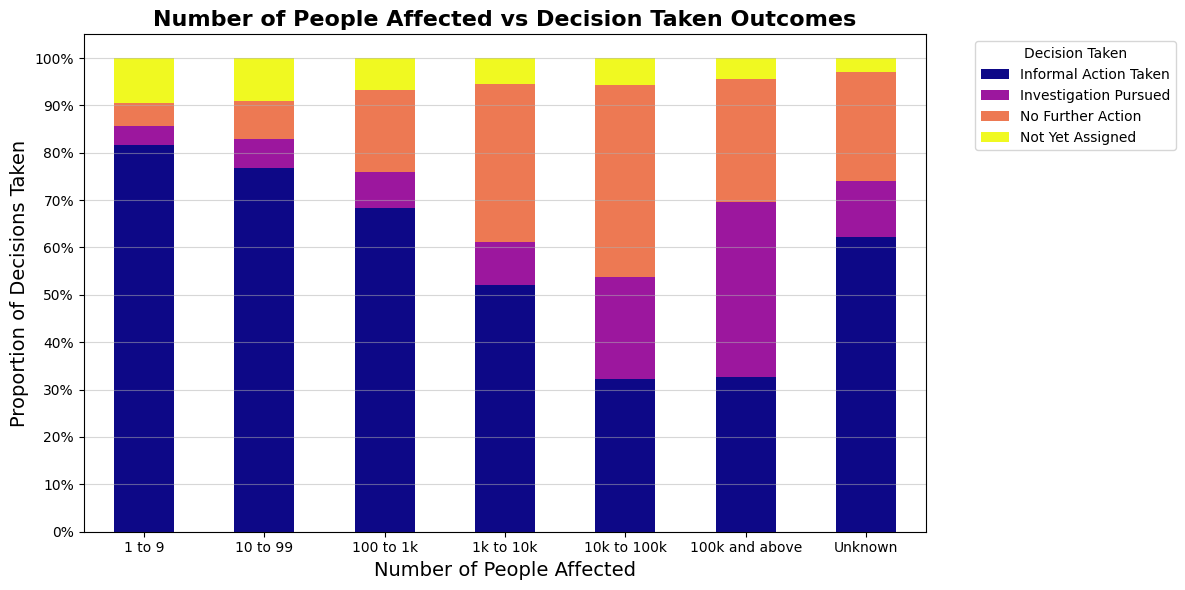

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action,Not Yet Assigned
no_data_subjects_affected,,,,
1 to 9,0.815,0.040,0.049,0.096
10 to 99,0.768,0.062,0.080,0.091
100 to 1k,0.684,0.074,0.174,0.068
1k to 10k,0.522,0.090,0.333,0.056
10k to 100k,0.322,0.217,0.406,0.056
100k and above,0.326,0.370,0.261,0.043
Unknown,0.621,0.119,0.229,0.030


In [88]:
# decision taken vs no. data subjects affected

# proportions
decision_severity_proportions = pd.crosstab(
    df_health_unique['no_data_subjects_affected'],
    df_health_unique['decision_taken'],
    normalize='index'
)
# counts
decision_severity_counts = pd.crosstab(
    df_health_unique['no_data_subjects_affected'],
    df_health_unique['decision_taken']
)
# bar chart
decision_severity_proportions.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='plasma'
)

plt.title('Number of People Affected vs Decision Taken Outcomes', fontsize=16, fontweight='bold')
plt.xlabel('Number of People Affected', fontsize=14)
plt.xticks(rotation=0, ha='center')
plt.ylabel('Proportion of Decisions Taken', fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.1), [f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)])
plt.legend(title='Decision Taken', bbox_to_anchor=(1.05, 1), loc='best')
plt.grid(True, axis='y', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

# table for the number of people affected vs decision taken proportions
decision_severity_proportions.round(3)


In [89]:
# table for the number of people affected vs decision taken counts
decision_severity_counts

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action,Not Yet Assigned
no_data_subjects_affected,,,,
1 to 9,5360,265,321,628
10 to 99,888,72,92,105
100 to 1k,527,57,134,52
1k to 10k,215,37,137,23
10k to 100k,46,31,58,8
100k and above,15,17,12,2
Unknown,619,119,228,30


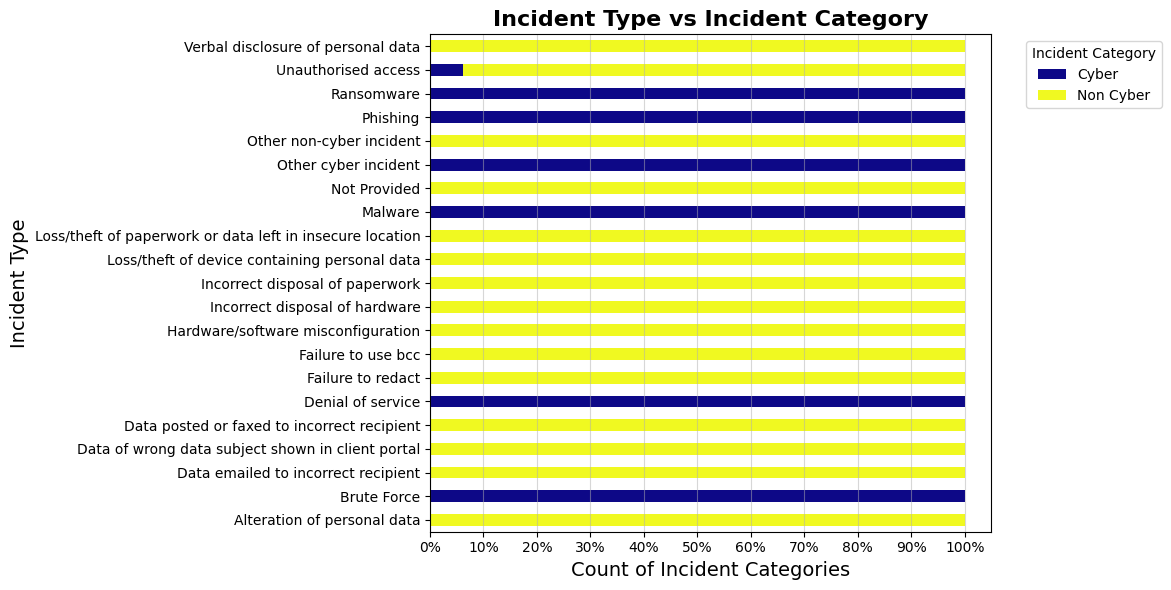

incident_category,Cyber,Non Cyber
incident_type,,
Alteration of personal data,0.000,1.000
Brute Force,1.000,0.000
Data emailed to incorrect recipient,0.000,1.000
Data of wrong data subject shown in client portal,0.000,1.000
Data posted or faxed to incorrect recipient,0.000,1.000
Denial of service,1.000,0.000
Failure to redact,0.000,1.000
Failure to use bcc,0.000,1.000
Hardware/software misconfiguration,0.000,1.000


In [90]:
# incident category vs incident Type

# proportions
incident_type_category_proportions = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['incident_category'],
    normalize='index'
)
# counts
incident_type_category_counts = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['incident_category']
)
# horizontal bar chart
incident_type_category_proportions.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 6),
    colormap='plasma'
)

plt.title('Incident Type vs Incident Category', fontsize=16, fontweight='bold')
plt.ylabel('Incident Type', fontsize=14)
plt.xlabel('Count of Incident Categories', fontsize=14)
plt.yticks(rotation=0, ha='right')
plt.xticks(np.arange(0, 1.1, 0.1), [f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)]) 
plt.legend(title='Incident Category', bbox_to_anchor=(1.05, 1), loc='best')
plt.grid(True, axis='x', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

# table for the incident type vs incident category proportions
incident_type_category_proportions.round(3)


In [91]:
# table for the incident type vs incident category counts
incident_type_category_counts

incident_category,Cyber,Non Cyber
incident_type,,
Alteration of personal data,0,30
Brute Force,17,0
Data emailed to incorrect recipient,0,1571
Data of wrong data subject shown in client portal,0,297
Data posted or faxed to incorrect recipient,0,1007
Denial of service,5,0
Failure to redact,0,407
Failure to use bcc,0,223
Hardware/software misconfiguration,0,339


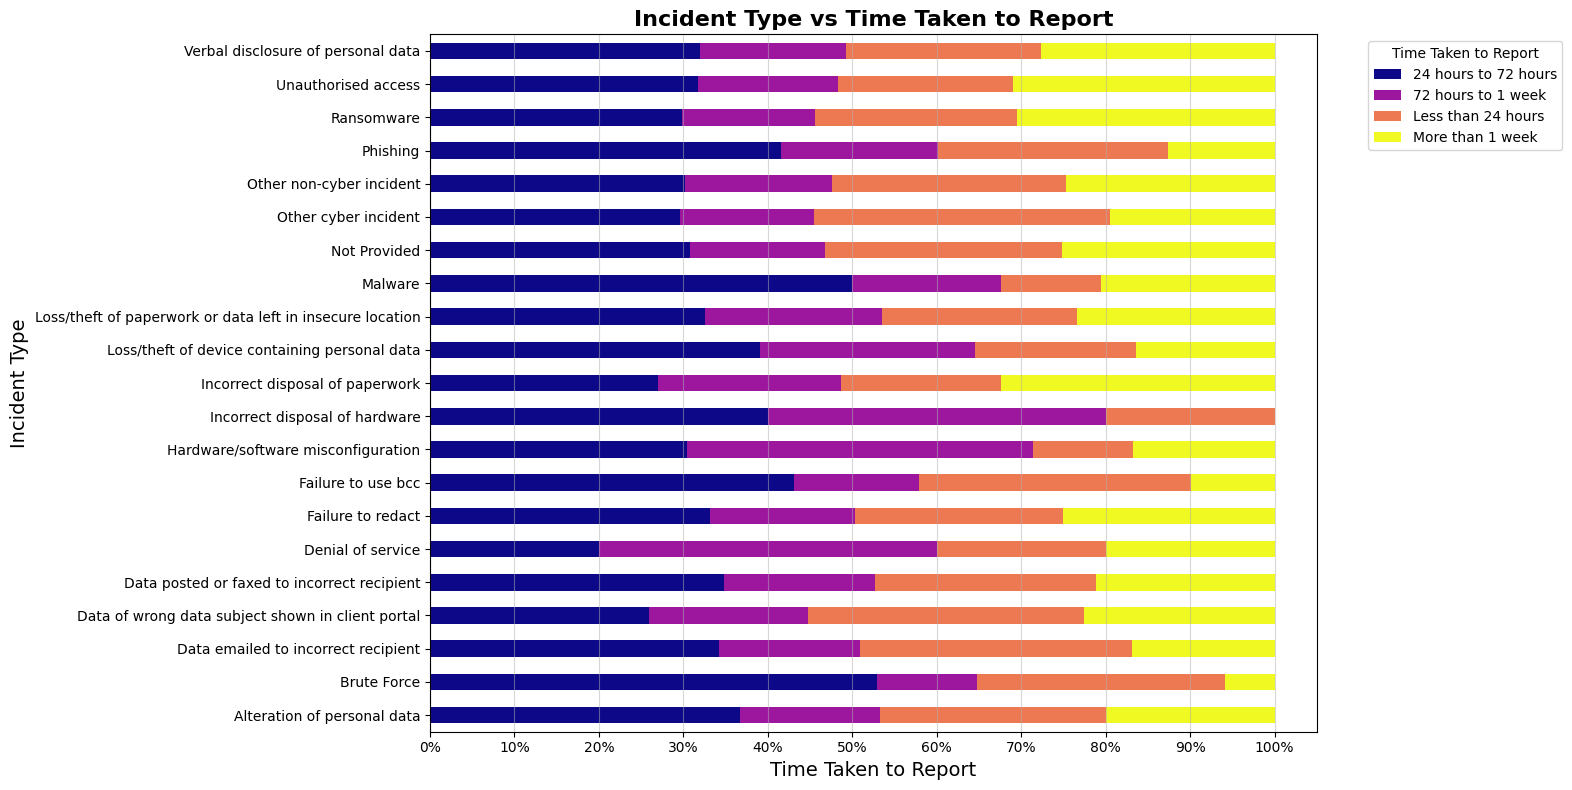

time_taken_to_report,24 hours to 72 hours,72 hours to 1 week,Less than 24 hours,More than 1 week
incident_type,,,,
Alteration of personal data,0.367,0.167,0.267,0.200
Brute Force,0.529,0.118,0.294,0.059
Data emailed to incorrect recipient,0.342,0.167,0.322,0.169
Data of wrong data subject shown in client portal,0.259,0.189,0.327,0.226
Data posted or faxed to incorrect recipient,0.349,0.179,0.261,0.212
Denial of service,0.200,0.400,0.200,0.200
Failure to redact,0.332,0.172,0.246,0.251
Failure to use bcc,0.430,0.148,0.323,0.099
Hardware/software misconfiguration,0.304,0.410,0.118,0.168


In [92]:
# incident type vs time taken to report

# proportions
incident_type_time_proportions = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['time_taken_to_report'],
    normalize='index'
)
# counts
incident_type_time_counts = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['time_taken_to_report']
)
# horizontal bar chart
incident_type_time_proportions.plot(
    kind='barh',
    stacked=True,
    figsize=(16, 8),
    colormap='plasma'
)

plt.title('Incident Type vs Time Taken to Report', fontsize=16, fontweight='bold')
plt.ylabel('Incident Type', fontsize=14)
plt.xlabel('Time Taken to Report', fontsize=14)
plt.yticks(rotation=0, ha='right')
plt.xticks(np.arange(0, 1.1, 0.1), [f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)]) 
plt.legend(title='Time Taken to Report', bbox_to_anchor=(1.05, 1), loc='best')
plt.grid(True, axis='x', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

# table for the incident type vs time taken to report proportions
incident_type_time_proportions.round(3)

In [93]:
# table for the incident type vs time taken to report counts
incident_type_time_counts

time_taken_to_report,24 hours to 72 hours,72 hours to 1 week,Less than 24 hours,More than 1 week
incident_type,,,,
Alteration of personal data,11,5,8,6
Brute Force,9,2,5,1
Data emailed to incorrect recipient,538,262,506,265
Data of wrong data subject shown in client portal,77,56,97,67
Data posted or faxed to incorrect recipient,351,180,263,213
Denial of service,1,2,1,1
Failure to redact,135,70,100,102
Failure to use bcc,96,33,72,22
Hardware/software misconfiguration,103,139,40,57


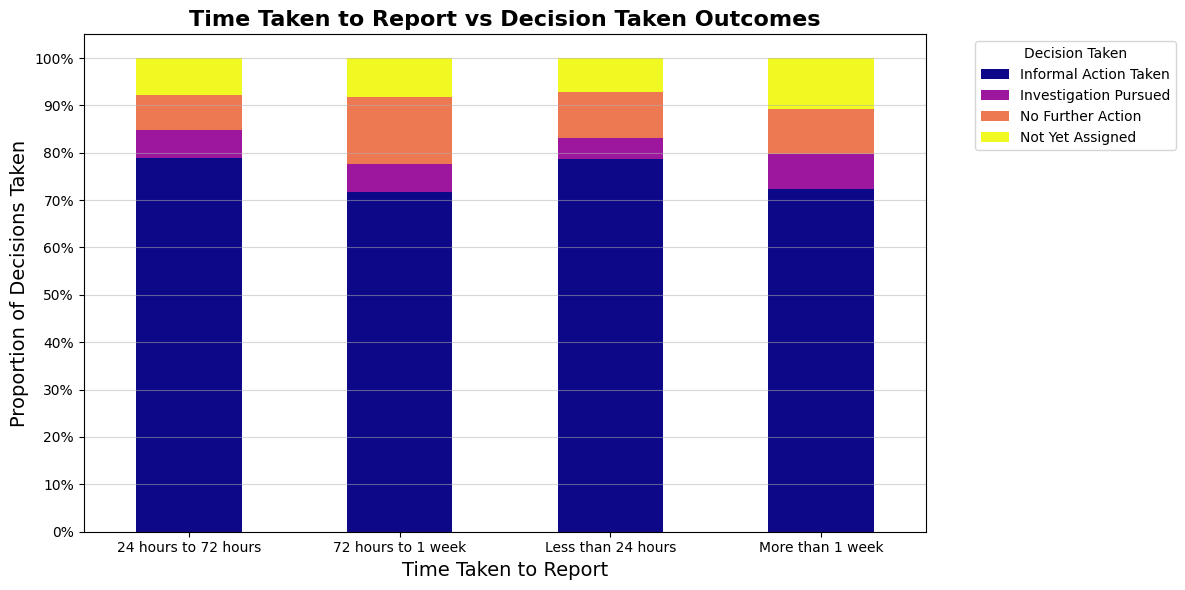

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action,Not Yet Assigned
time_taken_to_report,,,,
24 hours to 72 hours,0.788,0.059,0.075,0.078
72 hours to 1 week,0.717,0.059,0.141,0.083
Less than 24 hours,0.786,0.045,0.096,0.072
More than 1 week,0.723,0.076,0.095,0.107


In [94]:
# decision taken vs time taken to report

# proportions
decision_time_proportions = pd.crosstab(
    df_health_unique['time_taken_to_report'],
    df_health_unique['decision_taken'],
    normalize='index'
)
# counts
decision_time_counts = pd.crosstab(
    df_health_unique['time_taken_to_report'],
    df_health_unique['decision_taken']
)
# bar chart
decision_time_proportions.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='plasma'
)

plt.title('Time Taken to Report vs Decision Taken Outcomes', fontsize=16, fontweight='bold')
plt.xlabel('Time Taken to Report', fontsize=14)
plt.xticks(rotation=0, ha='center')
plt.ylabel('Proportion of Decisions Taken', fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.1), [f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)])
plt.legend(title='Decision Taken', bbox_to_anchor=(1.05, 1), loc='best')
plt.grid(True, axis='y', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()     

# table for the time taken to report vs decision taken proportions
decision_time_proportions.round(3)

In [95]:
# table for the time taken to report vs decision taken counts
decision_time_counts

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action,Not Yet Assigned
time_taken_to_report,,,,
24 hours to 72 hours,2597,194,247,256
72 hours to 1 week,1325,109,261,153
Less than 24 hours,2055,118,252,188
More than 1 week,1693,177,222,251



Number of People Affected across all Healthcare Incidents:
	1 to 9: 6,574 incidents (65.1%)
	10 to 99: 1,157 incidents (11.5%)
	100 to 1k: 770 incidents (7.6%)
	1k to 10k: 412 incidents (4.1%)
	10k to 100k: 143 incidents (1.4%)
	100k and above: 46 incidents (0.5%)
	Unknown: 996 incidents (9.9%)


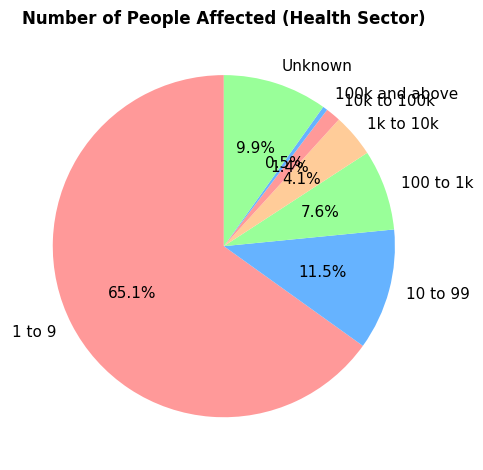


Incident Types across all Healthcare Incidents:
	Other non-cyber incident: 1,944 incidents (19.3%)
	Unauthorised access: 1,760 incidents (17.4%)
	Data emailed to incorrect recipient: 1,571 incidents (15.6%)
	Data posted or faxed to incorrect recipient: 1,007 incidents (10.0%)
	Loss/theft of paperwork or data left in insecure location: 806 incidents (8.0%)
	Verbal disclosure of personal data: 445 incidents (4.4%)
	Failure to redact: 407 incidents (4.0%)
	Hardware/software misconfiguration: 339 incidents (3.4%)
	Phishing: 301 incidents (3.0%)
	Data of wrong data subject shown in client portal: 297 incidents (2.9%)
	Ransomware: 285 incidents (2.8%)
	Failure to use bcc: 223 incidents (2.2%)
	Other cyber incident: 220 incidents (2.2%)
	Not Provided: 218 incidents (2.2%)
	Loss/theft of device containing personal data: 110 incidents (1.1%)
	Incorrect disposal of paperwork: 74 incidents (0.7%)
	Malware: 34 incidents (0.3%)
	Alteration of personal data: 30 incidents (0.3%)
	Brute Force: 17 inc

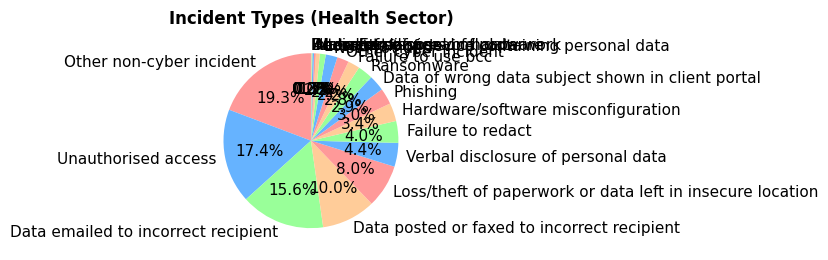


Time Taken to Report across all Healthcare Incidents:
	24 hours to 72 hours: 3,294 incidents (32.6%)
	Less than 24 hours: 2,613 incidents (25.9%)
	More than 1 week: 2,343 incidents (23.2%)
	72 hours to 1 week: 1,848 incidents (18.3%)


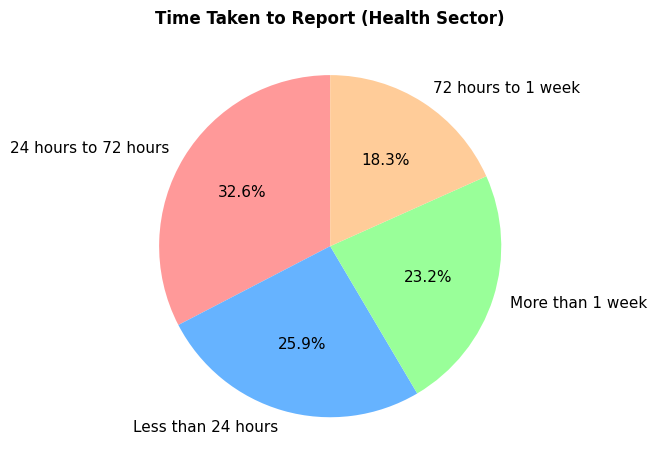

In [96]:
# proportion of number of people affected across all incidents
data_subjects_counts = df_health_unique['no_data_subjects_affected'].value_counts().sort_index()
data_subjects_percents = (data_subjects_counts / len(df_health_unique)) * 100
print(f"\nNumber of People Affected across all Healthcare Incidents:")
for category, count, percent in zip(data_subjects_counts.index, data_subjects_counts.values, data_subjects_percents.values):
    print(f"\t{category}: {count:,} incidents ({percent:.1f}%)")
    

# pie chart of number of people affected
plt.title("Number of People Affected (Health Sector)", fontsize=12, fontweight='bold')
plt.pie(data_subjects_counts.values,
        labels=data_subjects_counts.index,
        autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'],
        startangle=90,
        textprops={'fontsize': 11})
plt.tight_layout()
plt.show()

# proportion of incident type across all incidents
incident_type_counts = df_health_unique['incident_type'].value_counts()
incident_type_percents = (incident_type_counts / len(df_health_unique)) * 100
print(f"\nIncident Types across all Healthcare Incidents:")
for category, count, percent in zip(incident_type_counts.index, incident_type_counts.values, incident_type_percents.values):
    print(f"\t{category}: {count:,} incidents ({percent:.1f}%)")
    
# pie chart of incident types
plt.title("Incident Types (Health Sector)", fontsize=12, fontweight='bold')
plt.pie(incident_type_counts.values,
        labels=incident_type_counts.index,
        autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'],
        startangle=90,
        textprops={'fontsize': 11})
plt.tight_layout()
plt.show()

# proportion of time taken to report across all incidents
time_taken_counts = df_health_unique['time_taken_to_report'].value_counts()
time_taken_percents = (time_taken_counts / len(df_health_unique)) * 100
print(f"\nTime Taken to Report across all Healthcare Incidents:")
for category, count, percent in zip(time_taken_counts.index, time_taken_counts.values, time_taken_percents.values):
    print(f"\t{category}: {count:,} incidents ({percent:.1f}%)")
    
# pie chart of time taken to report
plt.title("Time Taken to Report (Health Sector)", fontsize=12, fontweight='bold')
plt.pie(time_taken_counts.values,
        labels=time_taken_counts.index,
        autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'],
        startangle=90,
        textprops={'fontsize': 11})
plt.tight_layout()
plt.show()

In [97]:
# make the df_health_original df a new csv file for the next stages of analysis
# check the columns and data types before saving
df_health_original.info()
#df_health_original.to_csv("data-security-incident-trends-health-sector.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 22879 entries, 65264 to 206136
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   bi_reference               22879 non-null  category
 1   year                       22879 non-null  category
 2   quarter                    22879 non-null  category
 3   data_subject_type          22879 non-null  category
 4   data_type                  22879 non-null  category
 5   decision_taken             22879 non-null  category
 6   incident_category          22879 non-null  category
 7   incident_type              22879 non-null  category
 8   no_data_subjects_affected  22879 non-null  category
 9   time_taken_to_report       22879 non-null  category
dtypes: category(10)
memory usage: 764.5 KB


In [98]:
# create a new df for ML models that includes unique incidents with aggregated data_subject_type and data_type features
df_health_ml = (
    df_health_original
    .groupby("bi_reference", observed=True)
    .agg({
        "year": "first",
        "quarter": "first",
        "data_subject_type": lambda data: ', '.join(sorted(data.unique())),
        "data_type": lambda data: ', '.join(sorted(data.unique())),
        "decision_taken": "first",
        "incident_category": "first",
        "incident_type": "first",
        "no_data_subjects_affected": "first",
        "time_taken_to_report": "first",
    })
    .reset_index()
)

# drop bi_reference as not needed for modelling
df_health_ml = df_health_ml.drop(columns=["bi_reference"])

# drop the 'Not Yet Assigned' rows as they aren't predictable 
df_health_ml = df_health_ml[df_health_ml["decision_taken"] != "Not Yet Assigned"].reset_index(drop=True)

# verify new df
df_health_ml.info()
df_health_ml.to_csv("new-data-security-incident-trends-health-sector.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9250 entries, 0 to 9249
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   year                       9250 non-null   category
 1   quarter                    9250 non-null   category
 2   data_subject_type          9250 non-null   object  
 3   data_type                  9250 non-null   object  
 4   decision_taken             9250 non-null   category
 5   incident_category          9250 non-null   category
 6   incident_type              9250 non-null   category
 7   no_data_subjects_affected  9250 non-null   category
 8   time_taken_to_report       9250 non-null   category
dtypes: category(7), object(2)
memory usage: 209.9+ KB


In [99]:
# check decision taken variables 
df_health_ml["decision_taken"].value_counts()

decision_taken
Informal Action Taken    7670
No Further Action         982
Investigation Pursued     598
Not Yet Assigned            0
Name: count, dtype: int64